In [1]:
from google.colab import files
uploaded = files.upload()

Saving SKAB.zip to SKAB.zip


In [3]:
!unzip -o SKAB.zip
!ls SKAB

Archive:  SKAB.zip
   creating: SKAB/
   creating: SKAB/anomaly-free/
  inflating: SKAB/anomaly-free/anomaly-free.csv  
   creating: SKAB/other/
  inflating: SKAB/other/11.csv       
  inflating: SKAB/other/12.csv       
  inflating: SKAB/other/13.csv       
  inflating: SKAB/other/14.csv       
  inflating: SKAB/other/15.csv       
  inflating: SKAB/other/16.csv       
  inflating: SKAB/other/17.csv       
  inflating: SKAB/other/18.csv       
  inflating: SKAB/other/19.csv       
  inflating: SKAB/other/20.csv       
  inflating: SKAB/other/21.csv       
  inflating: SKAB/other/22.csv       
  inflating: SKAB/other/23.csv       
  inflating: SKAB/other/9.csv        
   creating: SKAB/valve1/
  inflating: SKAB/valve1/0.csv       
  inflating: SKAB/valve1/1.csv       
  inflating: SKAB/valve1/10.csv      
  inflating: SKAB/valve1/11.csv      
  inflating: SKAB/valve1/12.csv      
  inflating: SKAB/valve1/13.csv      
  inflating: SKAB/valve1/14.csv      
  inflating: SKAB/valve1/15.csv

### Cell 2 — Imports

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score

### Cell 3 — Feature columns

In [5]:
base_features = [
    "Accelerometer1RMS",
    "Accelerometer2RMS",
    "Current",
    "Pressure",
    "Temperature",
    "Thermocouple",
    "Voltage",
    "Volume Flow RateRMS"
]

### Cell 4 — Rolling feature function

In [6]:
def add_rolling_features(df, feature_cols, window=5):
    df = df.copy()

    for col in feature_cols:
        df[f"{col}_roll_mean"] = df[col].rolling(window=window, min_periods=window).mean()
        df[f"{col}_roll_std"] = df[col].rolling(window=window, min_periods=window).std()

    df = df.dropna().reset_index(drop=True)
    return df

### Cell 5 — Load anomaly-free training data

In [7]:
train_path = "/content/SKAB/anomaly-free/anomaly-free.csv"

train_df = pd.read_csv(train_path, sep=";")
train_df.columns = train_df.columns.str.strip()

print(train_df.columns.tolist())
print(train_df.shape)
train_df.head()

['datetime', 'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']
(9401, 9)


,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS
0,2020-02-08 13:30:47,0.206030,0.277924,1.81019,0.382638,90.1740,26.7760,228.208,121.664
1,2020-02-08 13:30:48,0.204366,0.275727,2.66317,-0.273216,90.2836,26.7760,227.245,122.000
2,2020-02-08 13:30:49,0.206103,0.278526,2.63758,0.382638,89.8666,26.7821,237.872,122.000
3,2020-02-08 13:30:51,0.204775,0.276948,2.32851,0.382638,90.2192,26.7773,230.422,121.338
4,2020-02-08 13:30:52,0.206052,0.278141,2.53422,0.382638,90.1449,26.7773,219.454,121.664


### Cell 6 — Add rolling features to training data

In [8]:
train_df = add_rolling_features(train_df, base_features, window=5)

all_features = train_df.columns.tolist()
all_features = [col for col in all_features if col in base_features or "_roll_" in col]

print("Number of features:", len(all_features))
print(all_features)
print(train_df.shape)

Number of features: 24
['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'Accelerometer1RMS_roll_mean', 'Accelerometer1RMS_roll_std', 'Accelerometer2RMS_roll_mean', 'Accelerometer2RMS_roll_std', 'Current_roll_mean', 'Current_roll_std', 'Pressure_roll_mean', 'Pressure_roll_std', 'Temperature_roll_mean', 'Temperature_roll_std', 'Thermocouple_roll_mean', 'Thermocouple_roll_std', 'Voltage_roll_mean', 'Voltage_roll_std', 'Volume Flow RateRMS_roll_mean', 'Volume Flow RateRMS_roll_std']
(9397, 25)


### Cell 7 — Scale training data

In [9]:
X_train = train_df[all_features].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print("Scaled train shape:", X_train_scaled.shape)

Scaled train shape: (9397, 24)


### Cell 8 — Train Isolation Forest

In [10]:
if_model = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

if_model.fit(X_train_scaled)
print("Isolation Forest trained")

Isolation Forest trained


### Cell 9 — Set threshold from training scores

Very important: threshold comes from training-normal scores, not test scores.

In [27]:
train_scores = -if_model.decision_function(X_train_scaled)

threshold = np.percentile(train_scores, 99)

print("Train score min:", train_scores.min())
print("Train score max:", train_scores.max())
print("Threshold:", threshold)

Train score min: -0.1756215335315312
Train score max: 0.07651618621744893
Threshold: -3.9788864477502406e-16


### Cell 10 — Collect all labeled test files

In [28]:
test_files = glob.glob("/content/SKAB/*/*.csv")

test_files = [f for f in test_files if "anomaly-free" not in f]

print("Total test files found:", len(test_files))
for f in test_files[:10]:
    print(f)

Total test files found: 34
/content/SKAB/other/19.csv
/content/SKAB/other/11.csv
/content/SKAB/other/12.csv
/content/SKAB/other/23.csv
/content/SKAB/other/21.csv
/content/SKAB/other/17.csv
/content/SKAB/other/9.csv
/content/SKAB/other/22.csv
/content/SKAB/other/14.csv
/content/SKAB/other/18.csv


### Cell 11 — Evaluation loop for all test files

In [29]:
results = []

for file_path in test_files:
    try:
        df = pd.read_csv(file_path, sep=";")
        df.columns = df.columns.str.strip()

        if "anomaly" not in df.columns:
            continue

        df = add_rolling_features(df, base_features, window=5)

        if len(df) == 0:
            continue

        X_test = df[all_features].values
        y_test = df["anomaly"].values

        X_test_scaled = scaler.transform(X_test)

        scores = -if_model.decision_function(X_test_scaled)
        y_pred = (scores > threshold).astype(int)

        f1 = f1_score(y_test, y_pred, zero_division=0)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)

        if len(np.unique(y_test)) > 1:
            roc_auc = roc_auc_score(y_test, scores)
        else:
            roc_auc = np.nan

        cm = confusion_matrix(y_test, y_pred)

        results.append({
            "file": file_path,
            "rows": len(df),
            "true_anomalies": int(y_test.sum()),
            "pred_anomalies": int(y_pred.sum()),
            "f1": f1,
            "precision": precision,
            "recall": recall,
            "roc_auc": roc_auc,
            "tn": int(cm[0, 0]) if cm.shape == (2, 2) else np.nan,
            "fp": int(cm[0, 1]) if cm.shape == (2, 2) else np.nan,
            "fn": int(cm[1, 0]) if cm.shape == (2, 2) else np.nan,
            "tp": int(cm[1, 1]) if cm.shape == (2, 2) else np.nan,
        })

    except Exception as e:
        print(f"Error in file {file_path}: {e}")

### Cell 12 — Results table

In [30]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1", ascending=False).reset_index(drop=True)

print("Number of evaluated files:", len(results_df))
results_df.head(20)

Number of evaluated files: 34


,file,rows,true_anomalies,pred_anomalies,f1,precision,recall,roc_auc,tn,fp,fn,tp
0,/content/SKAB/other/11.csv,661,384,661,0.734928,0.580938,1.000000,0.568310,0,277,0,384
1,/content/SKAB/other/13.csv,964,398,964,0.584435,0.412863,1.000000,0.487375,0,566,0,398
2,/content/SKAB/other/19.csv,1322,587,865,0.577135,0.484393,0.713799,0.578171,289,446,168,419
3,/content/SKAB/valve2/3.csv,991,395,991,0.569986,0.398587,1.000000,0.476421,0,596,0,395
4,/content/SKAB/valve1/7.csv,1090,405,1090,0.541806,0.371560,1.000000,0.598118,0,685,0,405
5,/content/SKAB/other/20.csv,1187,451,1115,0.532567,0.373991,0.924612,0.383137,38,698,34,417
6,/content/SKAB/valve1/3.csv,1145,404,1145,0.521627,0.352838,1.000000,0.433262,0,741,0,404
7,/content/SKAB/valve1/15.csv,1146,404,1146,0.521290,0.352531,1.000000,0.570765,0,742,0,404
8,/content/SKAB/valve1/1.csv,1141,402,1141,0.521063,0.352323,1.000000,0.510654,0,739,0,402
9,/content/SKAB/valve1/6.csv,1150,405,1150,0.520900,0.352174,1.000000,0.559367,0,745,0,405


### Cell 13 — Overall summary

In [31]:
print("Average F1:", results_df["f1"].mean())
print("Average Precision:", results_df["precision"].mean())
print("Average Recall:", results_df["recall"].mean())
print("Average ROC-AUC:", results_df["roc_auc"].mean())

Average F1: 0.4936481663606851
Average Precision: 0.3671467525599415
Average Recall: 0.8724730026474153
Average ROC-AUC: 0.4976837706513031


### Cell 14 — See worst and best files

In [32]:
print("Best 5 files:")
display(results_df[["file", "f1", "precision", "recall", "roc_auc"]].head(5))

print("Worst 5 files:")
display(results_df[["file", "f1", "precision", "recall", "roc_auc"]].tail(5))

Best 5 files:


,file,f1,precision,recall,roc_auc
0,/content/SKAB/other/11.csv,0.734928,0.580938,1.000000,0.568310
1,/content/SKAB/other/13.csv,0.584435,0.412863,1.000000,0.487375
2,/content/SKAB/other/19.csv,0.577135,0.484393,0.713799,0.578171
3,/content/SKAB/valve2/3.csv,0.569986,0.398587,1.000000,0.476421
4,/content/SKAB/valve1/7.csv,0.541806,0.371560,1.000000,0.598118


Worst 5 files:


,file,f1,precision,recall,roc_auc
29,/content/SKAB/other/9.csv,0.412327,0.259705,1.000000,0.064866
30,/content/SKAB/other/22.csv,0.392459,0.276570,0.675516,0.333682
31,/content/SKAB/other/15.csv,0.377095,0.428571,0.336658,0.580338
32,/content/SKAB/other/16.csv,0.311844,0.323988,0.300578,0.516955
33,/content/SKAB/other/17.csv,0.139344,0.400000,0.084367,0.552203


### Cell 15 — Plot F1 per file

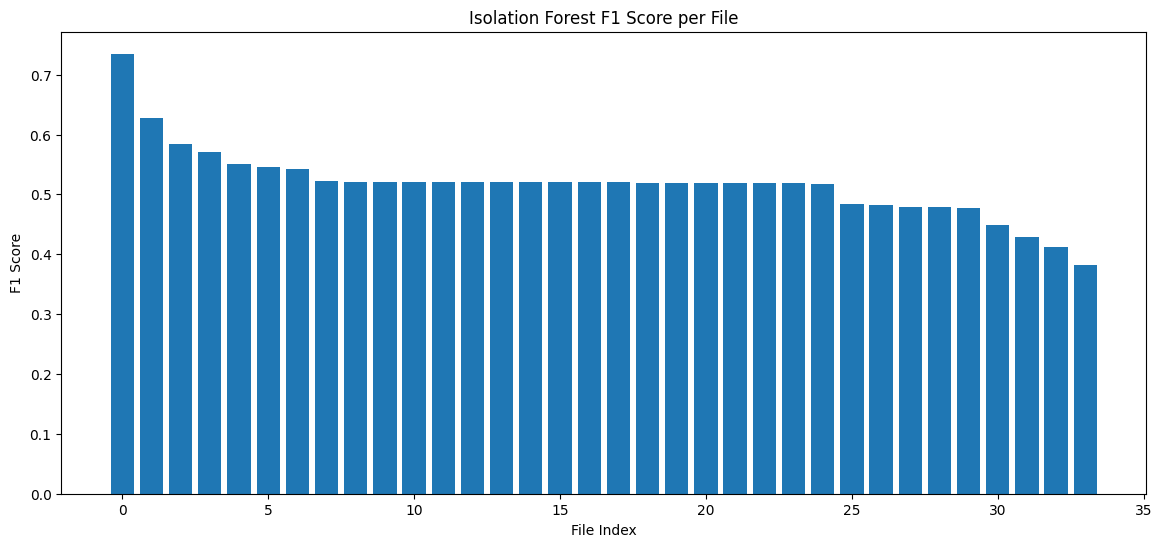

In [17]:
plt.figure(figsize=(14, 6))
plt.bar(range(len(results_df)), results_df["f1"])
plt.title("Isolation Forest F1 Score per File")
plt.xlabel("File Index")
plt.ylabel("F1 Score")
plt.show()

### Cell 16 — Check one file in detail

In [18]:
sample_file = results_df.iloc[0]["file"]
print(sample_file)

/content/SKAB/other/11.csv


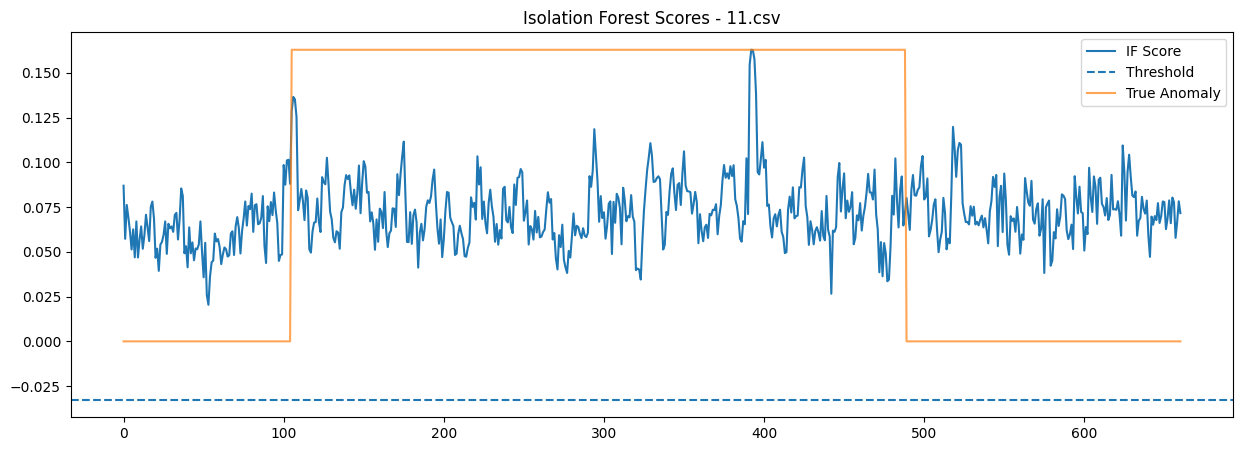

In [19]:
df = pd.read_csv(sample_file, sep=";")
df.columns = df.columns.str.strip()
df = add_rolling_features(df, base_features, window=5)

X_test = df[all_features].values
y_test = df["anomaly"].values
X_test_scaled = scaler.transform(X_test)

scores = -if_model.decision_function(X_test_scaled)
y_pred = (scores > threshold).astype(int)

plt.figure(figsize=(15, 5))
plt.plot(scores, label="IF Score")
plt.axhline(threshold, linestyle="--", label="Threshold")
plt.plot(y_test * scores.max(), label="True Anomaly", alpha=0.7)
plt.legend()
plt.title(f"Isolation Forest Scores - {os.path.basename(sample_file)}")
plt.show()